# Jump and Lévy Process Models Tutorial

This tutorial covers advanced models that go beyond Black-Scholes by incorporating jumps and fat tails:

1. **Merton Jump-Diffusion**: GBM + Poisson jumps
2. **Variance Gamma**: Pure-jump Lévy process

## Why These Models?

Black-Scholes assumes log-returns are normally distributed, but market returns exhibit:
- **Fat tails**: Extreme moves more frequent than Gaussian
- **Skewness**: Asymmetric return distribution
- **Volatility smile**: OTM options trade at higher implied vol

Jump and Lévy models address these limitations.

In [1]:
# Standard imports
import sys
sys.path.insert(0, '../../..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
## Part 1: Merton Jump-Diffusion Model

### Model Dynamics

The Merton model combines GBM with Poisson-distributed jumps:

$$\frac{dS_t}{S_t} = (r - q - \lambda\kappa)dt + \sigma dW_t + (J-1)dN_t$$

Where:
- $\sigma$: Diffusion volatility
- $\lambda$: Jump intensity (expected jumps per year)
- $J = e^Y$: Jump multiplier, $Y \sim N(\mu_J, \sigma_J^2)$
- $\kappa = E[J-1]$: Expected relative jump (drift correction)

In [2]:
from src.models.jump_diffusion import MertonParameters, MertonDynamics

# Define Merton parameters
merton_params = MertonParameters(
    sigma=0.2,      # 20% diffusion volatility
    lambda_=0.5,    # 0.5 jumps per year on average
    mu_j=-0.1,      # Mean log-jump (negative = crash-like)
    sigma_j=0.2,    # 20% jump size uncertainty
)

print("Merton Parameters:")
print(f"  Diffusion vol (σ): {merton_params.sigma:.1%}")
print(f"  Jump intensity (λ): {merton_params.lambda_} jumps/year")
print(f"  Expected jump E[J]: {merton_params.expected_jump:.4f}")
print(f"  Drift correction κ: {merton_params.kappa:.4f}")
print(f"  Total variance rate: {merton_params.total_variance_rate:.4f}")
print(f"  Equivalent BS vol: {merton_params.equivalent_bs_vol:.1%}")

Merton Parameters:
  Diffusion vol (σ): 20.0%
  Jump intensity (λ): 0.5 jumps/year
  Expected jump E[J]: 0.9231
  Drift correction κ: -0.0769
  Total variance rate: 0.0603
  Equivalent BS vol: 24.6%


### Simulating Merton Paths

In [3]:
# Create dynamics with risk-neutral drift
r, q = 0.05, 0.02  # Risk-free rate, dividend yield
merton_dynamics = MertonDynamics(params=merton_params, drift=r - q)

# Simulate paths
merton_sim = merton_dynamics.simulate(
    spot0=100.0,
    maturity=1.0,
    n_paths=10000,
    n_steps=252,
    seed=42,
)

print(f"Simulation Results:")
print(f"  Paths simulated: {merton_sim.n_paths}")
print(f"  Terminal spot mean: {merton_sim.terminal_spots.mean():.2f}")
print(f"  Expected (martingale): {100 * np.exp((r-q) * 1.0):.2f}")
print(f"  Average jumps per path: {merton_sim.average_jumps_per_path:.2f}")
print(f"  Paths with jumps: {merton_sim.jump_fraction:.1%}")

Simulation Results:
  Paths simulated: 10000
  Terminal spot mean: 102.73
  Expected (martingale): 103.05
  Average jumps per path: 0.51
  Paths with jumps: 40.1%


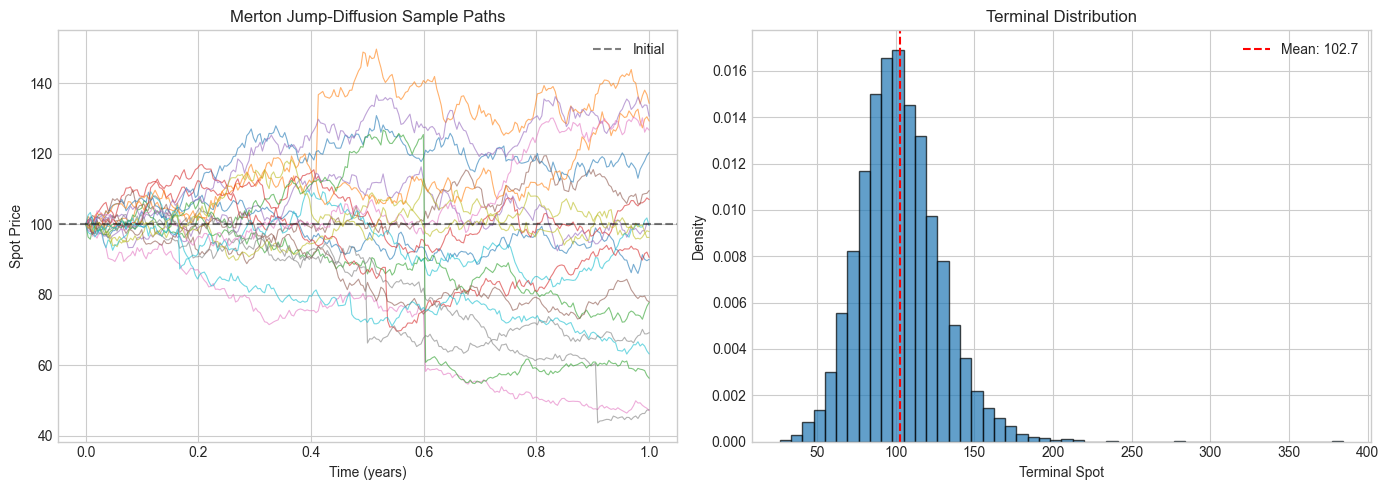

In [4]:
# Plot sample paths
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample paths
ax1 = axes[0]
for i in range(20):
    ax1.plot(merton_sim.times, merton_sim.spot_paths[i], alpha=0.6, linewidth=0.8)
ax1.axhline(y=100, color='black', linestyle='--', alpha=0.5, label='Initial')
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Spot Price')
ax1.set_title('Merton Jump-Diffusion Sample Paths')
ax1.legend()

# Terminal distribution
ax2 = axes[1]
ax2.hist(merton_sim.terminal_spots, bins=50, density=True, alpha=0.7, edgecolor='black')
ax2.axvline(x=merton_sim.terminal_spots.mean(), color='red', linestyle='--', label=f'Mean: {merton_sim.terminal_spots.mean():.1f}')
ax2.set_xlabel('Terminal Spot')
ax2.set_ylabel('Density')
ax2.set_title('Terminal Distribution')
ax2.legend()

plt.tight_layout()
plt.show()

### Merton vs Black-Scholes: Option Pricing

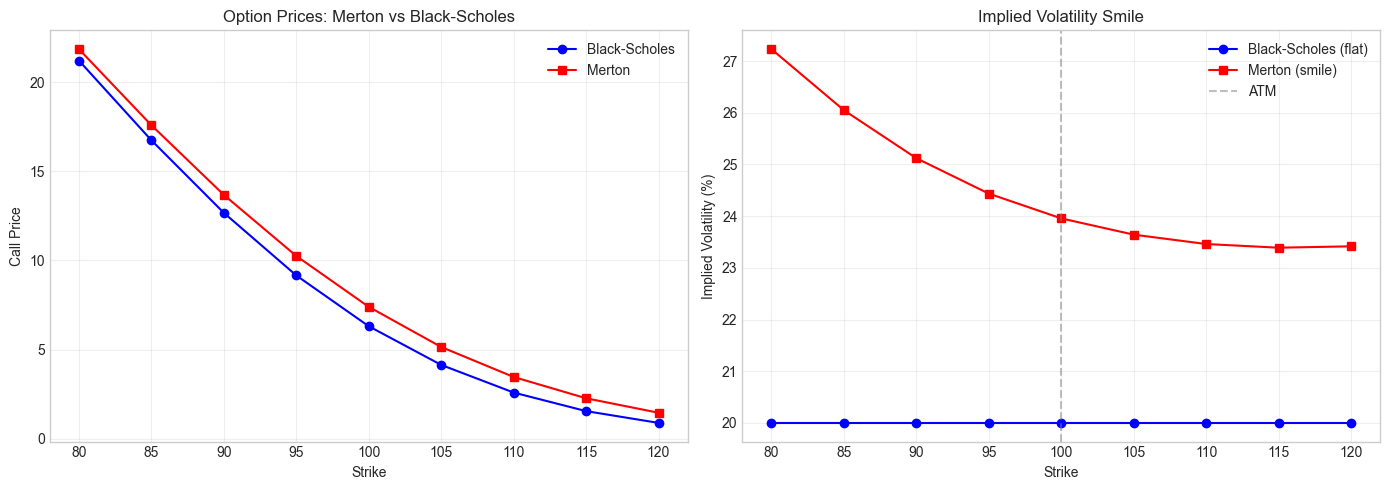

In [5]:
from src.models.jump_diffusion.merton import merton_european_call, merton_implied_vol

# Black-Scholes call price
def bs_call(S, K, T, r, q, sigma):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

# Price comparison
S, T = 100.0, 0.5
strikes = np.linspace(80, 120, 9)

bs_prices = [bs_call(S, K, T, r, q, 0.2) for K in strikes]
merton_prices = [merton_european_call(S, K, T, r, q, 0.2, 0.5, -0.1, 0.2) for K in strikes]

# Get implied vols
bs_iv = [0.2] * len(strikes)  # Constant by construction
merton_iv = [merton_implied_vol(S, K, T, r, q, 0.2, 0.5, -0.1, 0.2) for K in strikes]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices
ax1 = axes[0]
ax1.plot(strikes, bs_prices, 'b-o', label='Black-Scholes', markersize=6)
ax1.plot(strikes, merton_prices, 'r-s', label='Merton', markersize=6)
ax1.set_xlabel('Strike')
ax1.set_ylabel('Call Price')
ax1.set_title('Option Prices: Merton vs Black-Scholes')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Implied vol smile
ax2 = axes[1]
ax2.plot(strikes, np.array(bs_iv) * 100, 'b-o', label='Black-Scholes (flat)', markersize=6)
ax2.plot(strikes, np.array(merton_iv) * 100, 'r-s', label='Merton (smile)', markersize=6)
ax2.axvline(x=S, color='gray', linestyle='--', alpha=0.5, label='ATM')
ax2.set_xlabel('Strike')
ax2.set_ylabel('Implied Volatility (%)')
ax2.set_title('Implied Volatility Smile')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Effect of Jump Parameters

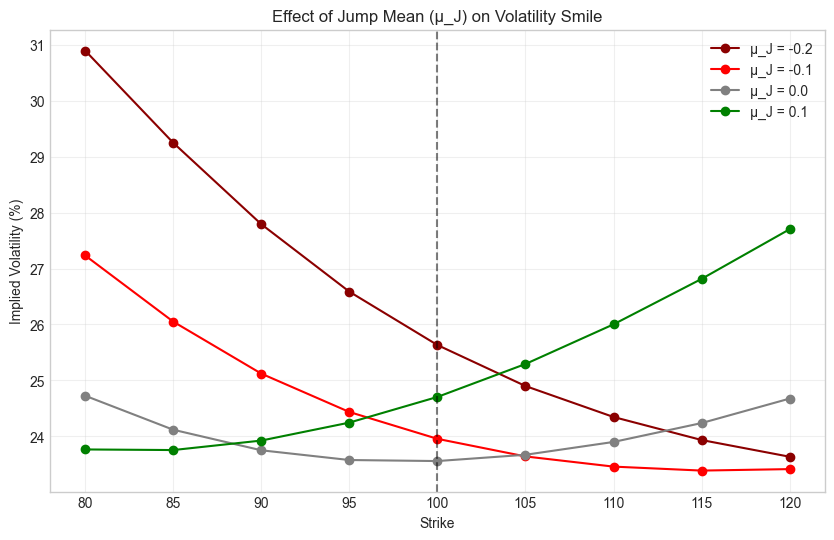

Key insight: Negative μ_J creates negative skew (higher OTM put implied vols)


In [6]:
# Compare different jump means
mu_j_values = [-0.2, -0.1, 0.0, 0.1]
colors = ['darkred', 'red', 'gray', 'green']

fig, ax = plt.subplots(figsize=(10, 6))

for mu_j, color in zip(mu_j_values, colors):
    iv = [merton_implied_vol(S, K, T, r, q, 0.2, 0.5, mu_j, 0.2) for K in strikes]
    ax.plot(strikes, np.array(iv) * 100, 'o-', color=color, label=f'μ_J = {mu_j}', markersize=6)

ax.axvline(x=S, color='black', linestyle='--', alpha=0.5)
ax.set_xlabel('Strike')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('Effect of Jump Mean (μ_J) on Volatility Smile')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print("Key insight: Negative μ_J creates negative skew (higher OTM put implied vols)")

---
## Part 2: Variance Gamma Model

### Model Construction

The Variance Gamma process is defined as time-changed Brownian motion:

$$X_t = \theta G_t + \sigma W_{G_t}$$

Where:
- $G_t \sim \text{Gamma}(t/\nu, \nu)$: Business time (Gamma process)
- $\theta$: Drift parameter (controls skewness)
- $\sigma$: Volatility parameter
- $\nu$: Variance rate of time (controls kurtosis/fat tails)

**Key difference from Merton**: VG is a **pure-jump** process (no diffusion component).

In [7]:
from src.models.levy import VarianceGammaParameters, VarianceGammaDynamics

# Define VG parameters
vg_params = VarianceGammaParameters(
    theta=-0.1,   # Negative drift (negative skew)
    sigma=0.2,    # Volatility
    nu=0.2,       # Variance rate of Gamma time
)

print("Variance Gamma Parameters:")
print(f"  Drift (θ): {vg_params.theta}")
print(f"  Volatility (σ): {vg_params.sigma:.1%}")
print(f"  Variance rate (ν): {vg_params.nu}")
print(f"  Martingale correction (ω): {vg_params.omega:.4f}")
print(f"  Variance rate: {vg_params.variance_rate:.4f}")
print(f"  Skewness: {vg_params.skewness:.4f}")
print(f"  Excess kurtosis: {vg_params.excess_kurtosis:.4f}")

Variance Gamma Parameters:
  Drift (θ): -0.1
  Volatility (σ): 20.0%
  Variance rate (ν): 0.2
  Martingale correction (ω): 0.0794
  Variance rate: 0.0420
  Skewness: -0.2881
  Excess kurtosis: 0.6558


### Simulating Variance Gamma Paths

In [8]:
# Create VG dynamics
vg_dynamics = VarianceGammaDynamics(params=vg_params, drift=r - q)

# Simulate paths
vg_sim = vg_dynamics.simulate(
    spot0=100.0,
    maturity=1.0,
    n_paths=10000,
    n_steps=252,
    seed=42,
)

print(f"VG Simulation Results:")
print(f"  Terminal spot mean: {vg_sim.terminal_spots.mean():.2f}")
print(f"  Expected (martingale): {100 * np.exp((r-q) * 1.0):.2f}")
print(f"  Average Gamma time G_T: {vg_sim.average_gamma_time:.3f} (expected: 1.0)")

VG Simulation Results:
  Terminal spot mean: 103.20
  Expected (martingale): 103.05
  Average Gamma time G_T: 0.998 (expected: 1.0)


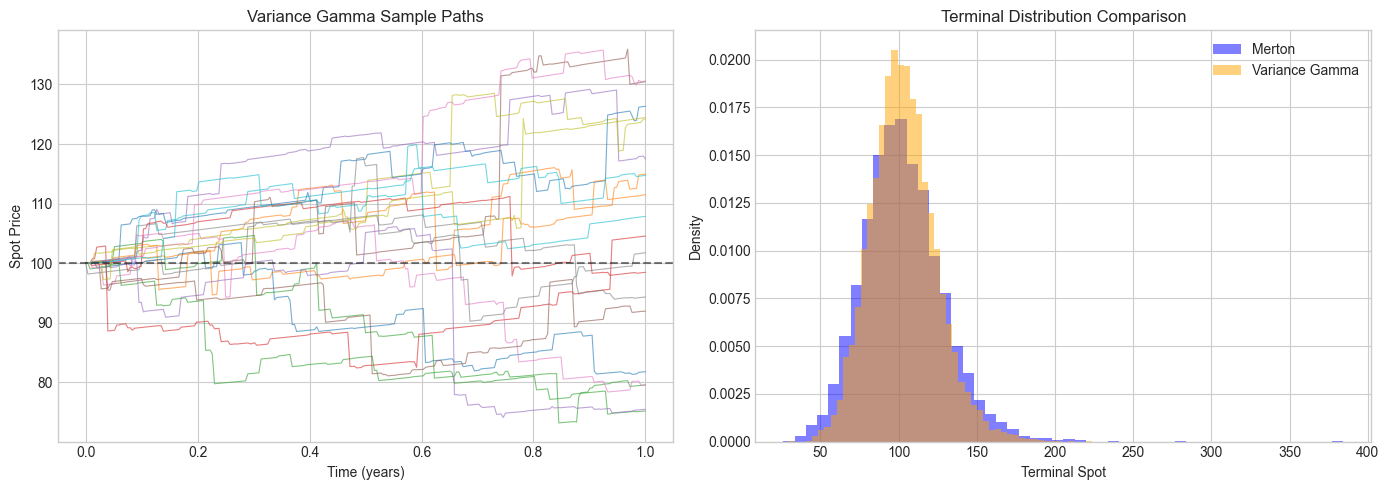

In [9]:
# Plot VG paths and distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample paths
ax1 = axes[0]
for i in range(20):
    ax1.plot(vg_sim.times, vg_sim.spot_paths[i], alpha=0.6, linewidth=0.8)
ax1.axhline(y=100, color='black', linestyle='--', alpha=0.5)
ax1.set_xlabel('Time (years)')
ax1.set_ylabel('Spot Price')
ax1.set_title('Variance Gamma Sample Paths')

# Terminal distribution comparison
ax2 = axes[1]
ax2.hist(merton_sim.terminal_spots, bins=50, density=True, alpha=0.5, label='Merton', color='blue')
ax2.hist(vg_sim.terminal_spots, bins=50, density=True, alpha=0.5, label='Variance Gamma', color='orange')
ax2.set_xlabel('Terminal Spot')
ax2.set_ylabel('Density')
ax2.set_title('Terminal Distribution Comparison')
ax2.legend()

plt.tight_layout()
plt.show()

### Effect of ν (Kurtosis Parameter)

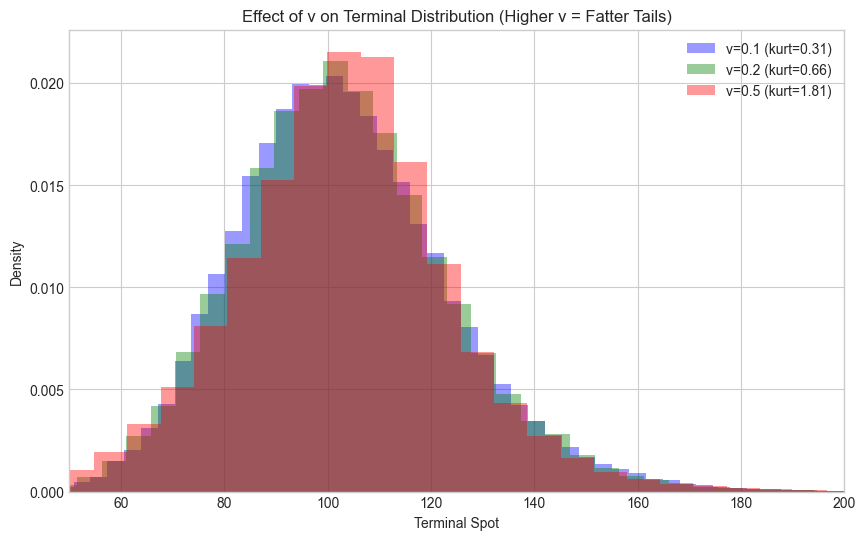

In [10]:
# Compare different nu values
nu_values = [0.1, 0.2, 0.5]
colors = ['blue', 'green', 'red']

fig, ax = plt.subplots(figsize=(10, 6))

for nu, color in zip(nu_values, colors):
    params = VarianceGammaParameters(theta=-0.1, sigma=0.2, nu=nu)
    dynamics = VarianceGammaDynamics(params=params, drift=r-q)
    S_T = dynamics.simulate_terminal(spot0=100, maturity=1.0, n_paths=50000, seed=42)
    
    ax.hist(S_T, bins=60, density=True, alpha=0.4, color=color, 
            label=f'ν={nu} (kurt={params.excess_kurtosis:.2f})')

ax.set_xlabel('Terminal Spot')
ax.set_ylabel('Density')
ax.set_title('Effect of ν on Terminal Distribution (Higher ν = Fatter Tails)')
ax.legend()
ax.set_xlim(50, 200)
plt.show()

---
## Part 3: Model Comparison and Use Cases

### Comparing Merton vs Variance Gamma vs Black-Scholes

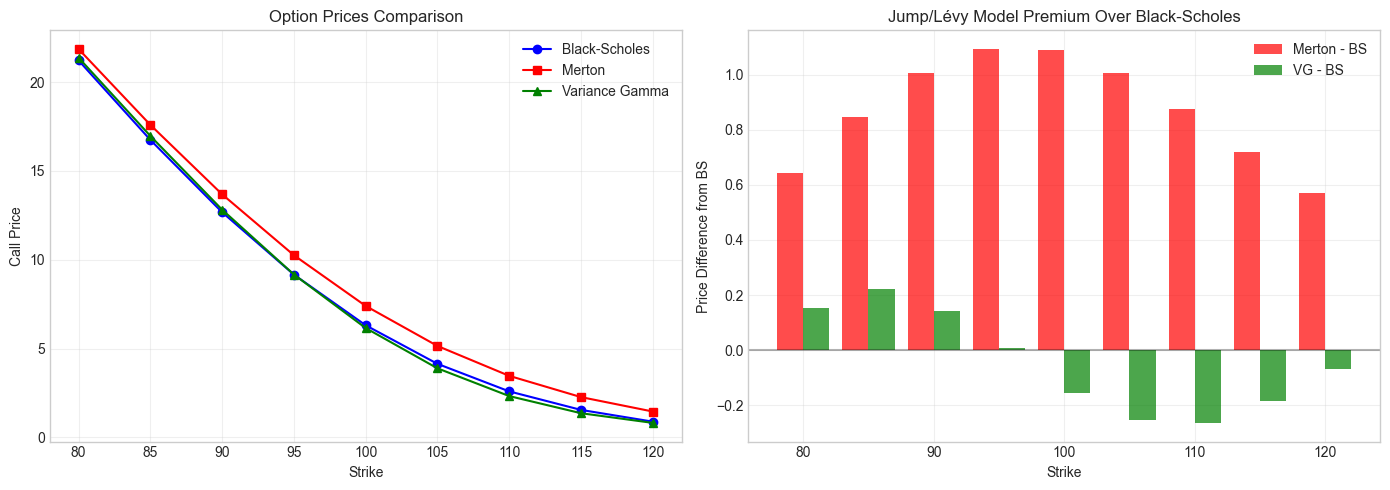

In [11]:
from src.models.levy.variance_gamma import vg_mc_call

# Price options across strikes
S, T = 100.0, 0.5
strikes = np.linspace(80, 120, 9)
n_mc = 100000

# Black-Scholes
bs_calls = [bs_call(S, K, T, r, q, 0.2) for K in strikes]

# Merton
merton_calls = [merton_european_call(S, K, T, r, q, 0.2, 0.5, -0.1, 0.2) for K in strikes]

# Variance Gamma (MC)
vg_calls = [vg_mc_call(S, K, T, r, q, vg_params, n_paths=n_mc, seed=42+i) for i, K in enumerate(strikes)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices
ax1 = axes[0]
ax1.plot(strikes, bs_calls, 'b-o', label='Black-Scholes', markersize=6)
ax1.plot(strikes, merton_calls, 'r-s', label='Merton', markersize=6)
ax1.plot(strikes, vg_calls, 'g-^', label='Variance Gamma', markersize=6)
ax1.set_xlabel('Strike')
ax1.set_ylabel('Call Price')
ax1.set_title('Option Prices Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Price differences from BS
ax2 = axes[1]
ax2.bar(strikes - 1, np.array(merton_calls) - np.array(bs_calls), width=2, alpha=0.7, label='Merton - BS', color='red')
ax2.bar(strikes + 1, np.array(vg_calls) - np.array(bs_calls), width=2, alpha=0.7, label='VG - BS', color='green')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax2.set_xlabel('Strike')
ax2.set_ylabel('Price Difference from BS')
ax2.set_title('Jump/Lévy Model Premium Over Black-Scholes')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Use Cases Summary

| Model | Best For | Key Feature |
|-------|----------|-------------|
| **Black-Scholes** | Simple, liquid options | Baseline |
| **Merton Jump-Diffusion** | Crash protection, event risk | Explicit crash modeling |
| **Variance Gamma** | Fat tails, parsimonious fit | 3-parameter smile |

### When to Use Each Model

**Black-Scholes:**
- Quick approximation
- ATM options
- Delta hedging calculations

**Merton Jump-Diffusion:**
- OTM puts (crash protection)
- Event-driven strategies
- When you want to model specific crash scenarios

**Variance Gamma:**
- General smile fitting with few parameters
- When you don't need explicit crash events
- Pure-jump alternatives to BSM

---
## Part 4: Practical Application - Pricing OTM Puts

In [12]:
from src.models.jump_diffusion.merton import merton_european_put
from src.models.levy.variance_gamma import vg_mc_put

def bs_put(S, K, T, r, q, sigma):
    d1 = (np.log(S/K) + (r - q + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)

# OTM put strikes (crash protection)
S, T = 100.0, 0.25  # 3-month options
put_strikes = np.array([85, 90, 95])

print("OTM Put Prices (Crash Protection):")
print(f"{'Strike':>8} {'BS':>10} {'Merton':>10} {'VG':>10} {'Merton %':>12} {'VG %':>10}")
print("-" * 60)

for K in put_strikes:
    bs_p = bs_put(S, K, T, r, q, 0.2)
    merton_p = merton_european_put(S, K, T, r, q, 0.2, 0.5, -0.1, 0.2)
    vg_p = vg_mc_put(S, K, T, r, q, vg_params, n_paths=100000, seed=42)
    
    merton_pct = (merton_p / bs_p - 1) * 100
    vg_pct = (vg_p / bs_p - 1) * 100
    
    print(f"{K:>8} {bs_p:>10.4f} {merton_p:>10.4f} {vg_p:>10.4f} {merton_pct:>+10.1f}% {vg_pct:>+8.1f}%")

print("\nKey insight: Jump/Lévy models price OTM puts higher than BS (crash premium)")

OTM Put Prices (Crash Protection):
  Strike         BS     Merton         VG     Merton %       VG %
------------------------------------------------------------
      85     0.1669     0.6518     0.3646     +290.5%   +118.4%
      90     0.6091     1.2281     0.8026     +101.6%    +31.8%
      95     1.6608     2.3453     1.6742      +41.2%     +0.8%

Key insight: Jump/Lévy models price OTM puts higher than BS (crash premium)


---
## Summary

### Key Takeaways

1. **Merton Jump-Diffusion**:
   - Combines GBM with Poisson jumps
   - Good for modeling specific crash events
   - 4 parameters: σ, λ, μ_J, σ_J
   - Has analytic (series) pricing formula

2. **Variance Gamma**:
   - Pure-jump Lévy process (no diffusion)
   - Controls skew (θ) and kurtosis (ν) independently
   - Only 3 parameters: θ, σ, ν
   - Good for parsimonious smile fitting

3. **Both models**:
   - Generate volatility smiles
   - Price OTM options higher than BS
   - Better fit to market data than BS

### Next Steps

- Explore [SABR Model Tutorial](sabr_model.ipynb) for stochastic volatility approach
- See technical references in `docs/reference/models/`